# **Projeto IA Dália - Análise do Dataset**

## **Informações:**

O CSV selecionado para iniciar os trabalhos foi um DataSet da plataforma Kaggle.

> URL:
>
> https://www.kaggle.com/datasets/csafrit2/maternal-health-risk-data

Esse CSV aborda registros coletados de diferentes hospitais, clínicas comunitárias e serviços de saúde materna por meio de um sistema de monitoramento de risco baseado em IOT.

### **Importando Bibliotecas e Materiais:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import boxplot as bp
import pingouin as pg
import itertools
from scipy.stats import mannwhitneyu

### **Abrindo Dataset:**

In [18]:
df = pd.read_csv("../data/raw/Maternal Health Risk Data Set.csv")

df.head(10)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.00,98.0,86,high risk
1,35,140,90,13.00,98.0,70,high risk
2,29,90,70,8.00,100.0,80,high risk
3,30,140,85,7.00,98.0,70,high risk
4,35,120,60,6.10,98.0,76,low risk
5,23,140,80,7.01,98.0,70,high risk
6,23,130,70,7.01,98.0,78,mid risk
7,35,85,60,11.00,102.0,86,high risk
8,32,120,90,6.90,98.0,70,mid risk
9,42,130,80,18.00,98.0,70,high risk


### **Extraindo Informações:**

In [3]:
df.shape

(1014, 7)

In [4]:
df.columns

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


> #### **Relatório**
> Temos 1.014 registros e 7 variáveis:
>
> | Coluna | Tipo | O que parece representar |
> | :--- | :--- | :--- |
> | **Age** | inteiro | idade |
> | **SystolicBP** | inteiro | pressão sistólica |
> | **DiastolicBP** | inteiro | pressão diastólica |
> | **BS** | decimal | glicemia |
> | **BodyTemp** | decimal | temperatura corporal |
> | **HeartRate** | inteiro | frequência cardíaca |
> | **RiskLevel** | texto | nível de risco — **nosso alvo**|
>
> - 0 valores nulos;
> - nenhuma coluna estranha de ID;
> - 6 variáveis numéricas + 1 categórica

In [6]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [7]:
df["RiskLevel"].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

> #### **Relatório**
> O `RiskLevel` está equilibrado:
>
> 🟢 Low risk: 406 → 40,0%
>
> 🟡 Mid risk: 336 → 33,1%
>
> 🔴 High risk: 272 → 26,8%

In [9]:
df.sort_values("HeartRate").head(10)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
908,16,120,75,7.9,98.0,7,low risk
499,16,120,75,7.9,98.0,7,low risk
783,12,120,95,6.8,98.0,60,mid risk
371,12,90,60,7.8,102.0,60,high risk
370,21,75,50,7.8,98.0,60,low risk
308,19,120,85,6.9,98.0,60,low risk
307,35,100,70,6.9,98.0,60,low risk
306,12,120,95,6.9,98.0,60,low risk
602,40,120,85,15.0,98.0,60,high risk
598,40,120,85,15.0,98.0,60,high risk


In [14]:
df.sort_values("BS", ascending=False).head(10)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
130,40,160,100,19.0,98.0,77,high risk
603,55,140,95,19.0,98.0,77,high risk
262,40,160,100,19.0,98.0,77,high risk
583,40,160,100,19.0,98.0,77,high risk
123,40,160,100,19.0,98.0,77,high risk
554,55,140,95,19.0,98.0,77,high risk
166,40,160,100,19.0,98.0,77,high risk
278,55,140,95,19.0,98.0,77,high risk
994,40,160,100,19.0,98.0,77,high risk
1002,55,140,95,19.0,98.0,77,high risk


In [11]:
df.nunique()

Age            50
SystolicBP     19
DiastolicBP    16
BS             29
BodyTemp        8
HeartRate      16
RiskLevel       3
dtype: int64

In [13]:
df[df["HeartRate"] < 40]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk


> #### **Relatório**
> O HeartRate = 7
>
> São exatamente dois registros, e eles são idênticos, e eles aparecem nos índices 499 e 908.
>
> Isso tem cara de erro de digitação/erro de coleta no dataset original. Uma frequência cardíaca de 7 bpm seria incompatível com um indivíduo vivo, então não faz sentido alimentar o modelo com isso como se fosse uma observação fisiológica válida.

In [15]:
df.duplicated().sum()

562

In [16]:
df[df.duplicated()]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
67,19,120,80,7.0,98.0,70,mid risk
72,19,120,80,7.0,98.0,70,mid risk
97,19,120,80,7.0,98.0,70,mid risk
106,50,140,90,15.0,98.0,90,high risk
107,25,140,100,6.8,98.0,80,high risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


In [17]:
df.duplicated().value_counts()

True     562
False    452
Name: count, dtype: int64

> #### **Relatório**
>
> Foram identificados 562 registros duplicados, correspondendo a aproximadamente 55,4% da base. 
>
> A presença de informações duplicadas deverá ser considerada na etapa de limpeza para evitar possível vazamento de informação entre os conjuntos de treinamento e teste.

In [19]:
df_unique = df.drop_duplicates()

df_unique["RiskLevel"].value_counts()

RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64

In [20]:
df_unique["RiskLevel"].value_counts(normalize=True) * 100

RiskLevel
low risk     51.769912
high risk    24.778761
mid risk     23.451327
Name: proportion, dtype: float64

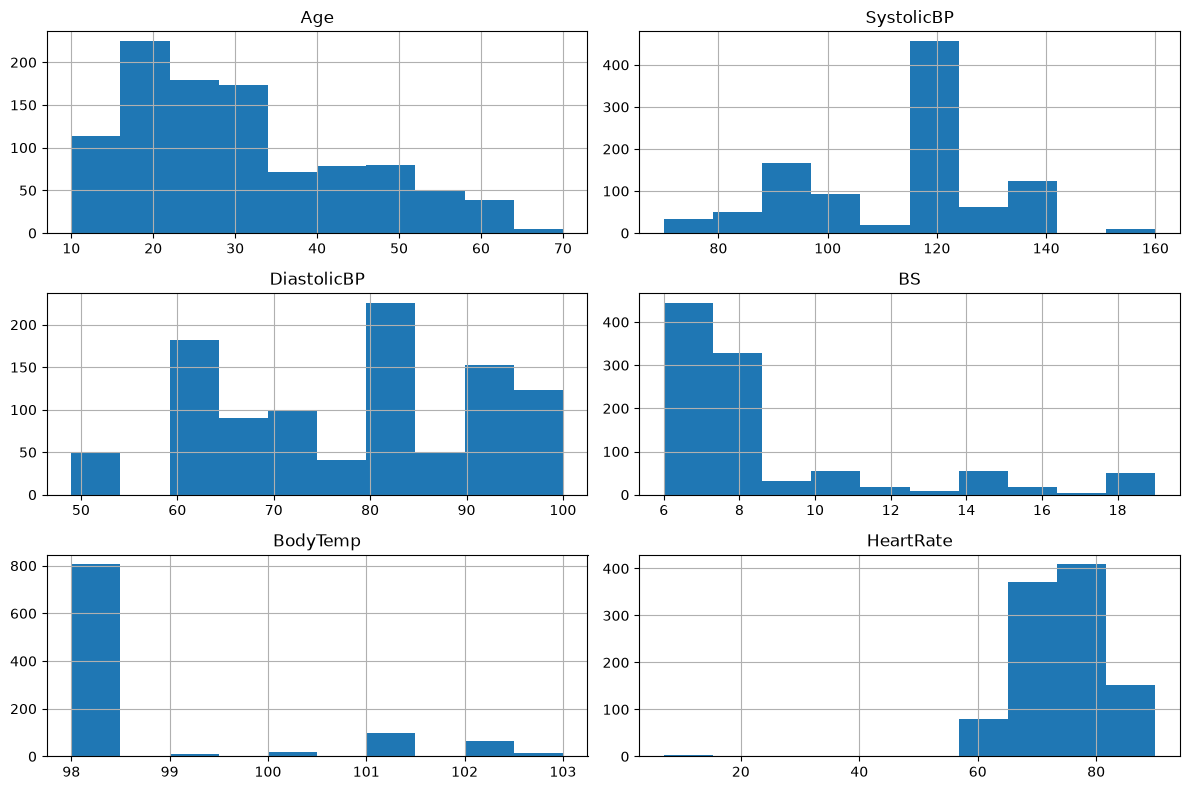

In [ ]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

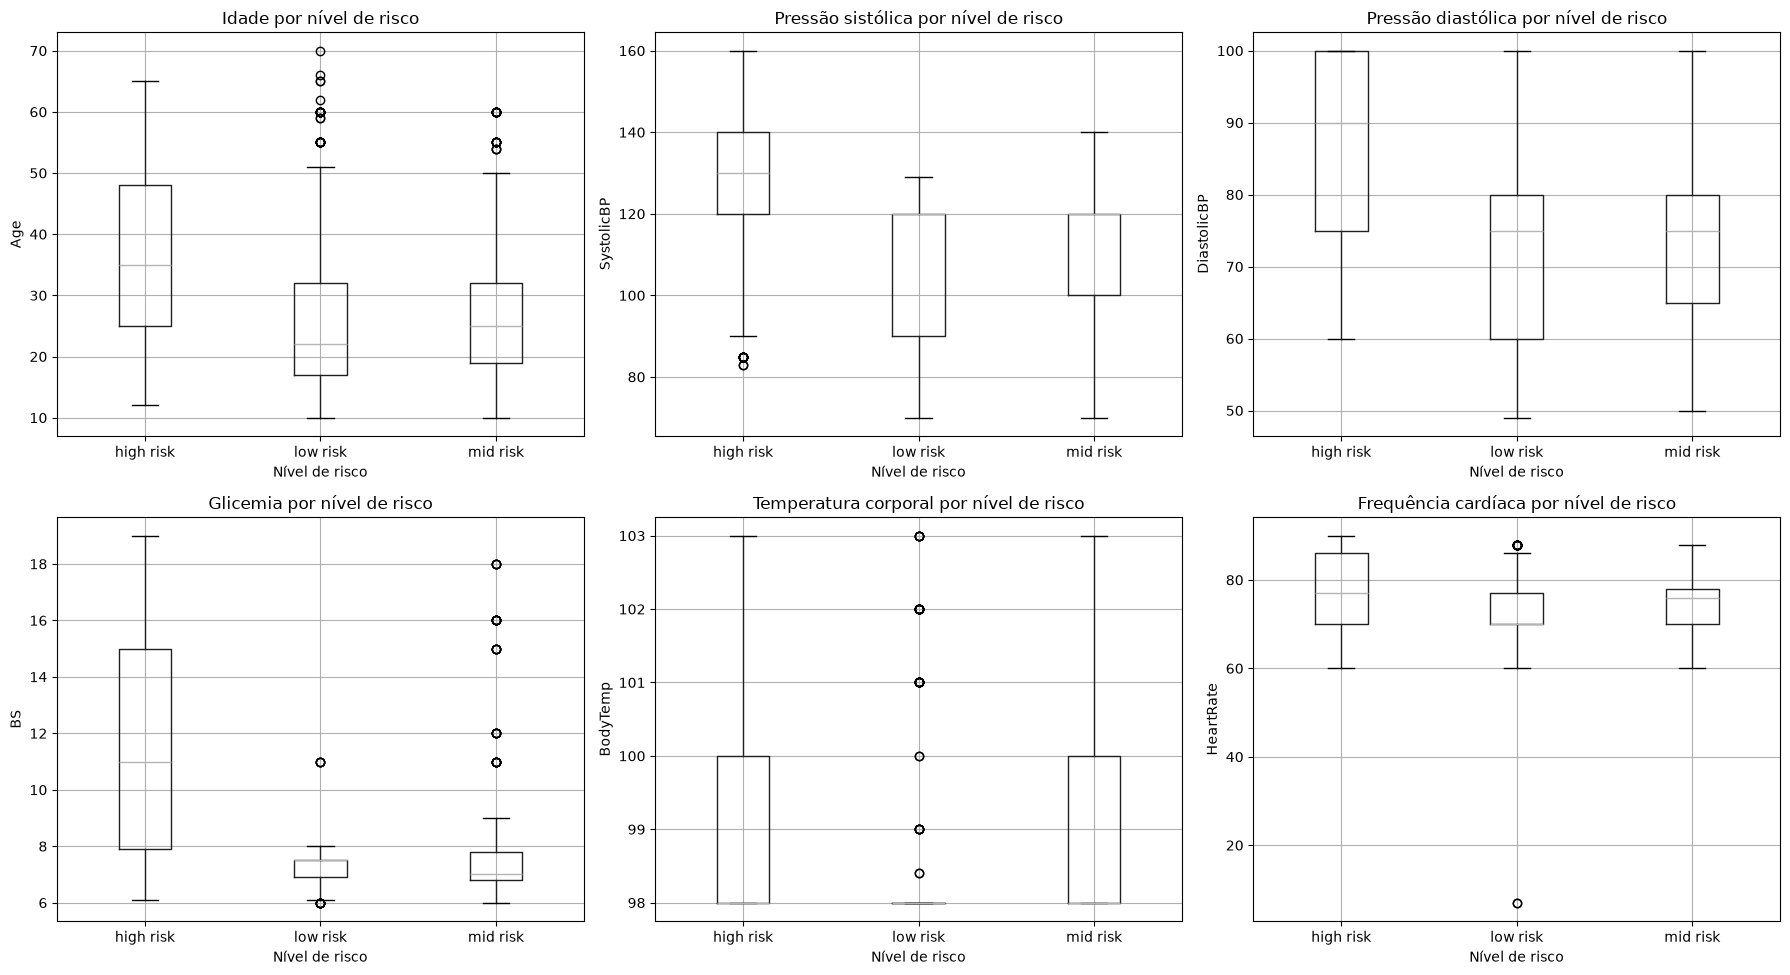

In [28]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

config = [
    ("Age", "Idade por nível de risco"),
    ("SystolicBP", "Pressão sistólica por nível de risco"),
    ("DiastolicBP", "Pressão diastólica por nível de risco"),
    ("BS", "Glicemia por nível de risco"),
    ("BodyTemp", "Temperatura corporal por nível de risco"),
    ("HeartRate", "Frequência cardíaca por nível de risco")
]

for i, (col, title) in enumerate(config):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    
    df.boxplot(column=col, by="RiskLevel", ax=ax)
    
    ax.set_title(title)
    ax.set_xlabel("Nível de risco")
    ax.set_ylabel(col)

plt.suptitle("")

plt.tight_layout()
plt.show()


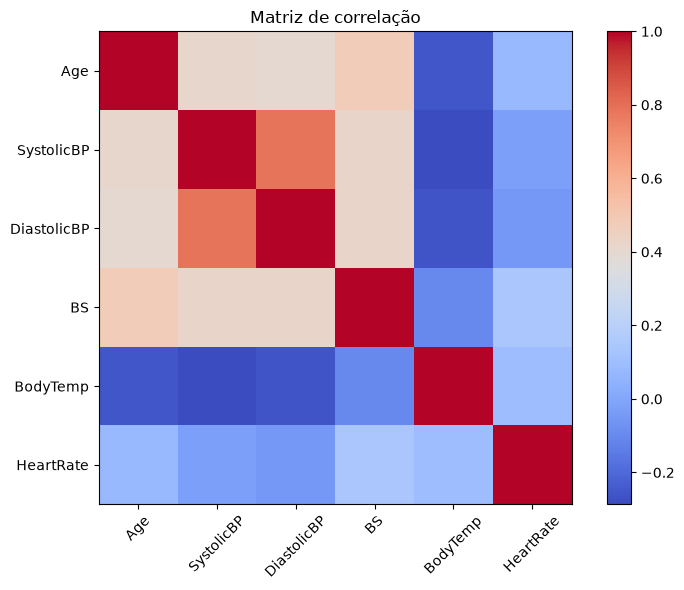

In [29]:
df_numeric = df.drop(columns=["RiskLevel"])

correlation = df_numeric.corr()

correlation

plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Matriz de correlação")
plt.tight_layout()
plt.show()

> #### **Diagnóstico Final**
>
> **Estrutura**
>
> 1.014 registros × 7 variáveis
>
> **Dados Ausentes**
>
> Nenhum valor nulo.
>
> **Classes Originais**
>
> | Risco | Registros |      % |
> | ----- | --------: | -----: |
> | Low   |       406 | 40,04% |
> | Mid   |       336 | 33,14% |
> | High  |       272 | 26,82% |
> 
> **Duplicadas**
>
> 562 registros duplicados → 55,42% da base.
>
> **Anomalia Encontrada**
>
> 2 registros com `HeartRate = 7`, ambos idênticos e classificados como `low risk`.